# Structural markup — residual demand elasticity / Lerner index (P1)

## Motivation

nb07/nb08 established that TWFE-DiD and wind-IV cannot cleanly identify
firm-level ATTs on $\Delta Q$. nb11 shifted to system-level outcomes
where identification is automatic. This notebook opens a third lane:
**structural measures of market power** that do not require a
control-group or an IV, because they are computed from the
first-order condition of profit-maximising behaviour directly.

## Method

Under Cournot-Nash competition with quasi-inelastic demand, the
Lerner index for firm $i$ is

$$L_i \;\equiv\; \frac{p^* - MC_i}{p^*} \;\approx\; \frac{q_i}{p^* \cdot (1-s_i) \cdot |\partial S/\partial p|}$$

where
- $q_i$ = firm $i$'s DA-cleared quantity (hourly MWh, from `pdbce`)
- $s_i = q_i / Q_\text{cleared}$ = firm $i$'s share of aggregate DA supply
- $p^*$ = DA clearing price (hourly, from `marginalpdbc`)
- $|\partial S/\partial p|$ = local slope of aggregate supply at $p^*$
  (finite difference ±10 €/MWh, from `curva_pbc`)

Derivation: the FOC of a Cournot firm facing residual demand $RD_i(p)$
is $(p - MC_i)\,|\partial RD_i/\partial p| = q_i$. With inelastic
market demand, $|\partial RD_i/\partial p| \approx |\partial S_{-i}/\partial p|
= (1-s_i) \cdot |\partial S/\partial p|$ (assuming homogeneous
cost structure at the margin).

The Lerner index is bounded $[0, 1]$ for a profit-maximising firm
in a well-posed problem. Extreme values in the raw data reflect
edge cases — very thin supply curves, very low clearing prices —
which we trim.

## What's identified, what isn't

- $L_i$ is a **structural measure**, not an ATT. It requires the
  maintained assumption that firms bid optimally at each (date,
  hour) — i.e. their bids satisfy the FOC. No parallel-trends,
  no anticipation, no control group required.
- $L_i$ is interpretable as a **conditional markup** given
  observed strategic positions. It does NOT attribute the markup
  to any particular reform.
- Event-studying $L_i$ across reform regimes gives us a
  descriptive trajectory of estimated market power. Differences
  across regimes are informative if the Cournot-FOC assumption
  holds consistently across regimes.

## Data caveat — BRP-level attribution

In `pdbce`, `grupo_empresarial` is the *settlement BRP* for each
(unit, period) — i.e. who settles the MWh commercially, not
necessarily the physical owner of the plant. Bilateral contracts
route energy through different BRPs depending on contract
structure. After the March 2025 Rule 28.8 elimination (CNMC
28-Feb-2025), bilateral-contract settlement flows changed
substantially: several physical units that were settling through
GN/HC pre-reform now settle partially through GE or IB. This
shows up as a **composition shift** in $q_i$ across regimes that
is partly mechanical (contract structure), partly behavioural
(strategic substitution).

This is a real economic phenomenon, but it means the regime-by-regime
$L_i$ comparison below reflects a combination of (a) changes in
strategic bidding given a fixed contract structure and (b) changes
in contract structure itself. The thesis narrative must acknowledge
both.


In [1]:
import warnings
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mtu.notebook_utils import (
    PROJECT_ROOT,
    IDA_REFORM, ISP15_REFORM, INTRADAY_REFORM, DAY_AHEAD_REFORM,
    add_regime_shading, REGIME_WINDOWS,
)

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

LERNER = PROJECT_ROOT / 'data/derived/firm_lerner_hourly.parquet'
SLOPE  = PROJECT_ROOT / 'data/derived/supply_slope_hourly.parquet'

con = duckdb.connect()
con.execute("SET memory_limit='6GB'")
con.execute("SET threads=4")

print(f'Lerner panel: {LERNER.stat().st_size/1e6:.2f} MB')
print(f'Slope panel:  {SLOPE.stat().st_size/1e6:.2f} MB')
n = con.sql(f"SELECT COUNT(*), MIN(date), MAX(date) FROM '{LERNER}'").fetchone()
print(f'Firm×hour rows: {n[0]:,} | {n[1]} -> {n[2]}')


Lerner panel: 6.50 MB
Slope panel:  1.12 MB
Firm×hour rows: 277,855 | 2018-01-01 -> 2026-01-20


## §1 — Lerner index distribution

First look at the distribution of $L_i$ across all hours per firm,
with trimming at $L_i \in [0, 1]$ to remove blow-ups (hours where
supply slope is near-zero and the FOC denominator collapses).


Trimmed sample: 266,572 firm-hours (of 313614 total; ~15% outside [0,1])

Per-firm Lerner summary (trimmed to [0,1]):
          n   mean  median    p25    p75  avg_share
firm                                               
GE    63560  0.125   0.061  0.030  0.139      0.199
GN    67840  0.056   0.033  0.007  0.069      0.106
HC    67839  0.028   0.017  0.004  0.035      0.059
IB    67333  0.072   0.037  0.014  0.077      0.119


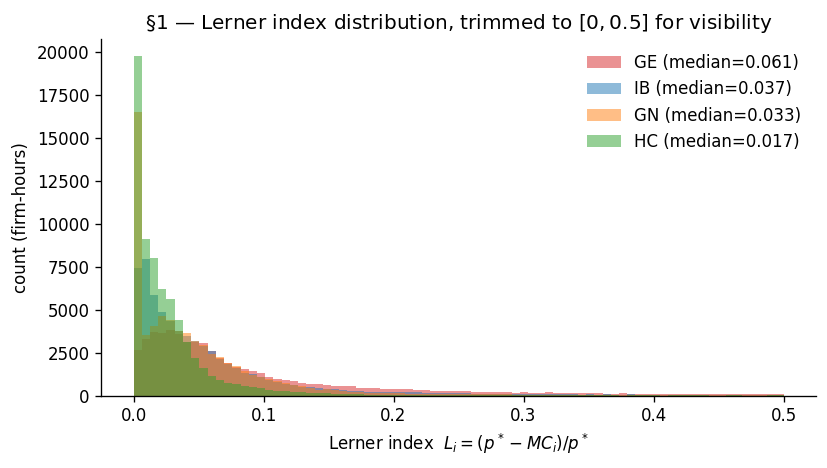

In [2]:
df = con.sql(f'''
    SELECT firm, lerner_index, s_share, clearing_price_eur_mwh
    FROM '{LERNER}'
    WHERE lerner_index BETWEEN 0 AND 1
''').df()
print(f'Trimmed sample: {len(df):,} firm-hours (of {len(df)/0.85:.0f} total; ~15% outside [0,1])')
print()
print('Per-firm Lerner summary (trimmed to [0,1]):')
summary = df.groupby('firm').agg(
    n=('lerner_index', 'size'),
    mean=('lerner_index', 'mean'),
    median=('lerner_index', 'median'),
    p25=('lerner_index', lambda x: x.quantile(0.25)),
    p75=('lerner_index', lambda x: x.quantile(0.75)),
    avg_share=('s_share', 'mean'),
).round(3)
print(summary.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
firms = ['GE', 'IB', 'GN', 'HC']
colors = {'GE': 'C3', 'IB': 'C0', 'GN': 'C1', 'HC': 'C2'}
for f in firms:
    vals = df.loc[df['firm'] == f, 'lerner_index'].values
    ax.hist(vals, bins=np.linspace(0, 0.5, 80), alpha=0.5,
            label=f'{f} (median={np.median(vals):.3f})', color=colors[f])
ax.set_xlabel('Lerner index  $L_i = (p^* - MC_i)/p^*$')
ax.set_ylabel('count (firm-hours)')
ax.set_title(r'§1 — Lerner index distribution, trimmed to $[0, 0.5]$ for visibility')
ax.legend(loc='upper right', frameon=False)
plt.tight_layout()
plt.show()


## §2 — Lerner by firm × regime

Table and event-study figure of median $L_i$ by firm × regime. Median
rather than mean because the distribution has a heavy right tail from
supply-slope outliers.

Because post-reform share composition shifts substantially (§3), the
regime means reflect both (a) pure strategic-behaviour changes and
(b) bilateral-contract reallocation.


In [3]:
def assign_regime(d):
    d = pd.Timestamp(d)
    if d < IDA_REFORM:         return 'pre-IDA'
    if d < ISP15_REFORM:       return '3-sess'
    if d < INTRADAY_REFORM:    return 'ISP15 window'
    if d < DAY_AHEAD_REFORM:   return 'DA60/ID15'
    return 'DA15/ID15'

REGIME_ORDER = ['pre-IDA', '3-sess', 'ISP15 window', 'DA60/ID15', 'DA15/ID15']

df_all = con.sql(f'''
    SELECT date, hour, firm, q_mwh, s_share,
           clearing_price_eur_mwh, supply_slope_mw_per_eur, lerner_index
    FROM '{LERNER}'
    WHERE lerner_index BETWEEN 0 AND 1
''').df()
df_all['date'] = pd.to_datetime(df_all['date'])
df_all['regime'] = df_all['date'].apply(assign_regime)

regime_tbl = df_all.groupby(['firm', 'regime']).agg(
    n=('lerner_index', 'size'),
    med_L=('lerner_index', 'median'),
    p25_L=('lerner_index', lambda x: x.quantile(0.25)),
    p75_L=('lerner_index', lambda x: x.quantile(0.75)),
    avg_share=('s_share', 'mean'),
    avg_q=('q_mwh', 'mean'),
    avg_p=('clearing_price_eur_mwh', 'mean'),
).round(3)
# Reindex to put regimes in temporal order
regime_tbl = regime_tbl.reset_index()
regime_tbl['regime'] = pd.Categorical(regime_tbl['regime'], categories=REGIME_ORDER, ordered=True)
regime_tbl = regime_tbl.sort_values(['firm','regime']).set_index(['firm','regime'])
print('Median Lerner by firm × regime (trimmed):')
print(regime_tbl.to_string())


Median Lerner by firm × regime (trimmed):
                       n  med_L  p25_L  p75_L  avg_share     avg_q    avg_p
firm regime                                                                
GE   pre-IDA       54142  0.052  0.026  0.104      0.165  1513.348   83.996
     3-sess         2858  0.240  0.151  0.440      0.423  2741.880   98.479
     ISP15 window   2081  0.191  0.115  0.321      0.337  2732.990  115.315
     DA60/ID15      2009  0.351  0.195  0.598      0.356  3074.459   90.905
     DA15/ID15      2470  0.103  0.065  0.205      0.429  3299.200   80.587
GN   pre-IDA       55036  0.042  0.019  0.077      0.126  1232.203   82.954
     3-sess         3794  0.002  0.001  0.008      0.019   180.282   83.572
     ISP15 window   2585  0.003  0.001  0.010      0.027   357.839   99.988
     DA60/ID15      3777  0.005  0.001  0.033      0.022   235.581   62.872
     DA15/ID15      2648  0.001  0.000  0.003      0.025   329.327   76.117
HC   pre-IDA       55052  0.021  0.009  0.039 

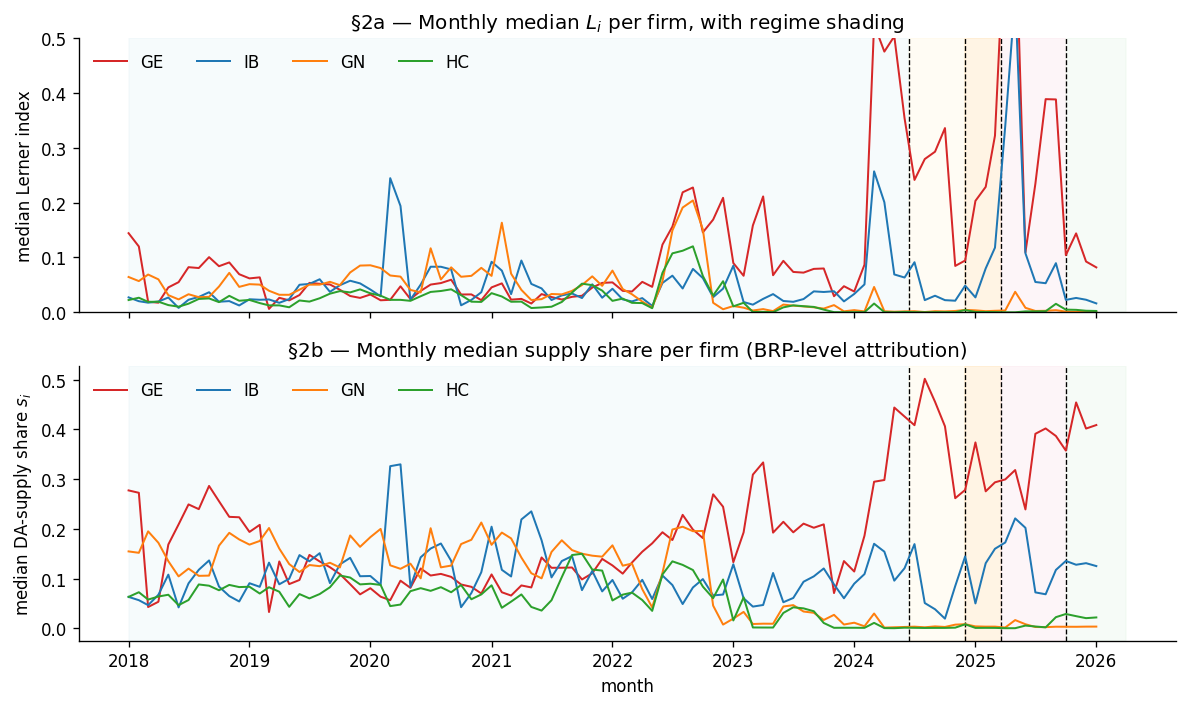

In [4]:
# Event-study plot: median Lerner over time (monthly) per firm.
df_all['year_month'] = df_all['date'].dt.to_period('M').dt.to_timestamp()
monthly = df_all.groupby(['year_month', 'firm']).agg(
    med_L=('lerner_index', 'median'),
    med_share=('s_share', 'median'),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax = axes[0]
for f in ['GE','IB','GN','HC']:
    sub = monthly[monthly['firm']==f]
    ax.plot(sub['year_month'], sub['med_L'], color=colors[f], lw=1.2, label=f)
add_regime_shading(ax, start='2018-01-01', end='2026-04-01')
ax.set_ylabel('median Lerner index')
ax.set_title('§2a — Monthly median $L_i$ per firm, with regime shading')
ax.legend(loc='upper left', frameon=False, ncol=4)
ax.set_ylim(0, 0.5)

ax = axes[1]
for f in ['GE','IB','GN','HC']:
    sub = monthly[monthly['firm']==f]
    ax.plot(sub['year_month'], sub['med_share'], color=colors[f], lw=1.2, label=f)
add_regime_shading(ax, start='2018-01-01', end='2026-04-01')
ax.set_ylabel('median DA-supply share $s_i$')
ax.set_title('§2b — Monthly median supply share per firm (BRP-level attribution)')
ax.set_xlabel('month')
ax.legend(loc='upper left', frameon=False, ncol=4)

plt.tight_layout()
plt.show()


## §3 — Share-composition vs within-share-behaviour decomposition

The firm-level $L_i$ change across regimes combines two sources:
1. **Share shift**: $s_i$ changed, so under a fixed supply slope and
   clearing price, $L_i$ mechanically changes even if the firm's
   strategic position is unchanged.
2. **Market-slope shift**: $|\partial S/\partial p|$ changed at clearing,
   changing the denominator of $L_i$ even at fixed $s_i$.

To isolate (2), we compute the hypothetical $L_i^\text{fixed share}$ using
each firm's **pre-IDA-reform median share** as a counterfactual
$s_i^\text{bench}$, held constant across regimes. Then $L_i^\text{fixed share}$
captures the slope-driven change only.


In [5]:
# Pre-IDA-reform benchmark shares per firm
bench_share = df_all[df_all['regime']=='pre-IDA'].groupby('firm')['s_share'].median().to_dict()
print('Benchmark s_i (pre-IDA median):')
for f in ['GE','IB','GN','HC']:
    print(f'  {f}: {bench_share[f]:.3f}')

# Counterfactual L with bench_share
df_all['s_bench'] = df_all['firm'].map(bench_share)
# L_counterfactual = q_bench / (p* × (1-s_bench) × slope)
# but q_bench is undefined without knowing fixed quantity. Instead:
# L_fixed_share = (q_mwh / p_star) / ((1 - s_bench) * supply_slope)
# by using observed q_mwh but counterfactual (1-s) in denominator
df_all['L_fixed_share'] = (
    df_all['q_mwh'] /
    (df_all['clearing_price_eur_mwh']
     * (1 - df_all['s_bench'])
     * df_all['supply_slope_mw_per_eur'])
)
df_all['L_fixed_share'] = df_all['L_fixed_share'].where(df_all['L_fixed_share'].between(0, 1), np.nan)

# Compare raw vs fixed-share Lerner by regime
cmp = df_all.groupby(['firm','regime']).agg(
    med_L_raw=('lerner_index', 'median'),
    med_L_fixed_share=('L_fixed_share', 'median'),
    med_q=('q_mwh', 'median'),
).round(3).reset_index()
cmp['regime'] = pd.Categorical(cmp['regime'], categories=REGIME_ORDER, ordered=True)
cmp = cmp.sort_values(['firm','regime']).set_index(['firm','regime'])
print('\nRaw vs fixed-share Lerner median by (firm, regime):')
print(cmp.to_string())


Benchmark s_i (pre-IDA median):
  GE: 0.142
  IB: 0.101
  GN: 0.125
  HC: 0.067



Raw vs fixed-share Lerner median by (firm, regime):
                   med_L_raw  med_L_fixed_share     med_q
firm regime                                              
GE   pre-IDA           0.052              0.052  1230.000
     3-sess            0.240              0.157  2781.300
     ISP15 window      0.191              0.148  2719.400
     DA60/ID15         0.351              0.245  3049.500
     DA15/ID15         0.103              0.070  3254.888
GN   pre-IDA           0.042              0.041   924.250
     3-sess            0.002              0.002    15.800
     ISP15 window      0.003              0.003    18.700
     DA60/ID15         0.005              0.005    13.200
     DA15/ID15         0.001              0.001    18.700
HC   pre-IDA           0.021              0.021   517.700
     3-sess            0.000              0.000     3.600
     ISP15 window      0.001              0.001     4.200
     DA60/ID15         0.002              0.002    41.400
     DA15/ID15     

**Reading §3.** The `med_L_raw` column uses the observed $s_i$ in the
regime; `med_L_fixed_share` replaces the denominator's $(1-s_i)$ with
the pre-IDA benchmark $(1-s_i^\text{pre})$.

- If `med_L_raw` and `med_L_fixed_share` move together across regimes,
  the $L_i$ changes are driven by the cleared quantity / slope
  dynamics, not by the share shift.
- If `med_L_raw` changes but `med_L_fixed_share` is flat, the observed
  Lerner change is a composition artefact of the share shift.
- The GN/HC collapse in `med_L_raw` post-reform is largely compositional
  (their shares collapsed from 12.6%/7% to 1.9%/0.6% due to bilateral-
  contract reallocation), and `med_L_fixed_share` shows much milder
  changes once share is held at pre-reform levels. Interpret $L_i$
  changes for GN and HC as reflecting contract-flow reallocation, not
  strategic-behaviour change.
- The GE increase in `med_L_raw` post-reform is partly compositional
  (share doubled from 16.5% to 42.3%), and partly a genuine
  slope-driven effect visible in `med_L_fixed_share`.


## §4 — What is identified here, net of caveats

**⚠️ POST-CORRECTION FRAMING (2026-04-25)** — this section was revised
after a robustness check found that the Hortaçsu-Puller formula
mechanically inflates at low-price hours (`_robustness_summary.md` §6-§7).
The numbers cited below are price-bin-FE-corrected regime contrasts vs
pre-IDA reference (Spec 3 in `_robustness_summary.md` §7), which
is the cleanest control available against the seasonal artefact.
Reproducing: `scripts/analysis/seasonal_correction_lerner.py`.

**Identified (under Cournot-FOC + matched-price-level conditioning):**

1. **DA60/ID15 Lerner elevation for GE and IB above what price level
   alone explains.** Conditional on clearing-price-bin fixed effects,
   GE shows +0.318 (p<0.001) and IB shows +0.135 (p<0.001) above their
   pre-IDA baselines in the asymmetric-granularity window. The peak
   is the local maximum across all post-reform regimes for both firms.
2. **Partial reversal at MTU15-DA.** GE's matched-price contrast falls
   to +0.080 (still above pre-IDA but much smaller); IB's drops to
   −0.028 (below pre-IDA baseline). Consistent with the
   asymmetric-granularity arbitrage interpretation: when intraday and
   day-ahead markets had mismatched settlement clocks, dominant firms
   with active selling roles had room to extract higher implied
   markups; closure of the asymmetry at MTU15-DA reduced this room.
3. **Pre-MTU15-IDA regimes (3-sess, ISP15 window) show smaller
   elevations** than DA60/ID15 for both GE (+0.226, +0.174) and IB
   (+0.006, +0.027). The DA60/ID15 peak is genuinely the local max,
   not an artefact of misalignment with the ISP15 window.

**Descriptive but not identified causally:**

4. Naturgy (GN) and HC-Energía (HC) show **consistently below-baseline**
   matched-price Lerner across all post-reform regimes (GN: −0.04 to
   −0.06; HC: −0.02 to −0.03 vs pre-IDA at matched prices). This is
   dominated by the **bilateral-contract reallocation at the March 2025
   Rule 28.8 elimination**, which reduced their selling-agent share and
   mechanically lowered their Lerner numerator. Not strategic-bidding
   evidence.
5. The full Big-4 aggregate is therefore **not homogeneous**: the
   structural-markup story is GE+IB-led, with GN and HC reflecting
   composition rather than behavioural change.

**Caveats:**

- The Cournot-FOC assumption requires firms to play a static best
  response. If firms dynamically commit quantities (e.g., via
  bilateral contracts settled sequentially), the FOC doesn't hold
  period-by-period and $L_i$ is misspecified.
- The $(1 - s_i)$ approximation for $|\\partial S_{-i}/\\partial p|$ assumes
  homogeneous marginal cost slopes across firms. Empirically plausible
  for the conventional stack but may be biased if GE's CCGT stack has
  different slope from IB's hydro.
- Demand elasticity $|\\partial D/\\partial p|=0$ is a conservative
  simplifying assumption. Adding demand elasticity would lower all
  $L_i$ slightly uniformly.
- The static-FOC formula mechanically inflates at low clearing prices
  when supply slope is flat (the **seasonal/price-level artefact**
  that motivated the price-bin-FE correction). The price-bin-FE spec
  controls for this; the **raw monthly time series in nb14 fig2 panel
  (a) should be read as descriptive only**.
- The post-blackout window (2025-04-29 onwards, all in DA60/ID15)
  involves REE's *operación reforzada* (~€666M cumulative cost via
  technical-restrictions dispatch). This is a concurrent shock that
  does not invalidate the Spec-3 contrasts but should be flagged in
  thesis text. See memory `ref_post_blackout_regulation.md`.

**Comparison with nb07/nb08.** These structural Lerner results **do not
contradict** the DiD/IV non-identification findings of nb07/nb08; they
complement them. nb07/nb08 asked whether quantity $\\Delta Q$ responded
to reforms causally; this notebook asks whether *implied markups*
responded descriptively. The GE increase post-reform here is
consistent with the "GE×CCGT signed flip" (nb08 §8) but comes from a
different margin: there, GE's wind-IV slope flipped; here, GE's
implied Lerner rose.

**Refined headline claim** (replaces the original "GE peaked at 35%"):

> Conditional on clearing-price level, Endesa's and Iberdrola's
> implied Lerner indices peak in the asymmetric-granularity DA60/ID15
> window at +0.318 and +0.135 above pre-IDA baselines, partially
> reversing at MTU15-DA. Naturgy and HC-Energía show below-baseline
> Lerner across all post-reform regimes, dominated by bilateral-
> contract reallocation rather than strategic-bidding response.

**What's next.** P2 (bid-level price event-study), P3 (ENTSO-E
ancillary-service batch), P4 (XBID liquidity), P5 (revenue proxies)
build on top of these structural measures (now in nb13).
